In [ ]:
import matplotlib.pyplot as plt
import albumentations as A
from ultralytics import YOLO
from pathlib import Path
import yaml
import os
from collections import Counter


# 1. Kiểm tra dữ liệu có số lượng dataset và tên classes

In [3]:
DATASET_PATH = Path("/Users/mac/Detect_Drill_Bit/final-dataset")
DATA_YAML = "/Users/mac/Detect_Drill_Bit/final-dataset/data.yaml"

with open(DATA_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

CLASS_NAMES = data_config["names"]
NUM_ClASSES = data_config["nc"]

print(CLASS_NAMES)
print(NUM_ClASSES)

['Broken', 'Chipped', 'Scratched', 'Severe_Rust', 'Tip_Wear']
5


# 2. Đếm dữ liệu cho từng bộ dữ liệu

In [4]:
def check_dataset():
    total_images = 0
    total_labels = 0
    for split in ["train", "val", "test/Bright_Field", "test/Dark_Field"]:
        img_path = DATASET_PATH / split / 'images'
        label_path = DATASET_PATH / split / 'labels'
        
        # glob dùng để tìm kiếm file, * là tìm kiếm tất cả, ? khớp với ký tự bất kỳ, [seq]: khớp với bất kỳ ký tự nào trong ngoặc vuông
        # suffix dùng để lấy đuôi file
        # đếm ảnh
        images = [f for f in img_path.glob("*") if f.suffix.lower() in [".jpg", ".png", ".png"]]
        num_images = print(f"images trong tập {split}", len(images))

        labels = list(label_path.glob("*.txt"))
        print(f"labels trong tập {split}", len(labels))        
        
        total_images += len(images)
        total_labels += len(labels)
    return total_images, total_labels

total_images, total_labels = check_dataset()
print("Tổng số lượng ảnh: ", total_images)
print("Tổng số lượng labels: ", total_labels)

images trong tập train 3521
labels trong tập train 3521
images trong tập val 744
labels trong tập val 744
images trong tập test/Bright_Field 292
labels trong tập test/Bright_Field 292
images trong tập test/Dark_Field 254
labels trong tập test/Dark_Field 254
Tổng số lượng ảnh:  4811
Tổng số lượng labels:  4811


# 3. Phân tích labels

In [6]:
def analyze_labels():
    class_counts = Counter()
    total_boxes = 0
    total_labels = 0

    for split in ["train", "val", "test/Bright_Field", "test/Dark_Field"]:
        label_path = DATASET_PATH / split / "labels"
        label_files = list(label_path.glob("*.txt"))

        for label_file in label_files:
            with open(label_file, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    class_counts[class_id] += 1
                    total_boxes += 1
    return class_counts, total_boxes
class_counts, total_boxes = analyze_labels()
print(class_counts, total_boxes)

Counter({2: 1787, 3: 1650, 1: 1403, 4: 1226, 0: 1065}) 7131


# 4. Visualize Phân Bố Dữ Liệu

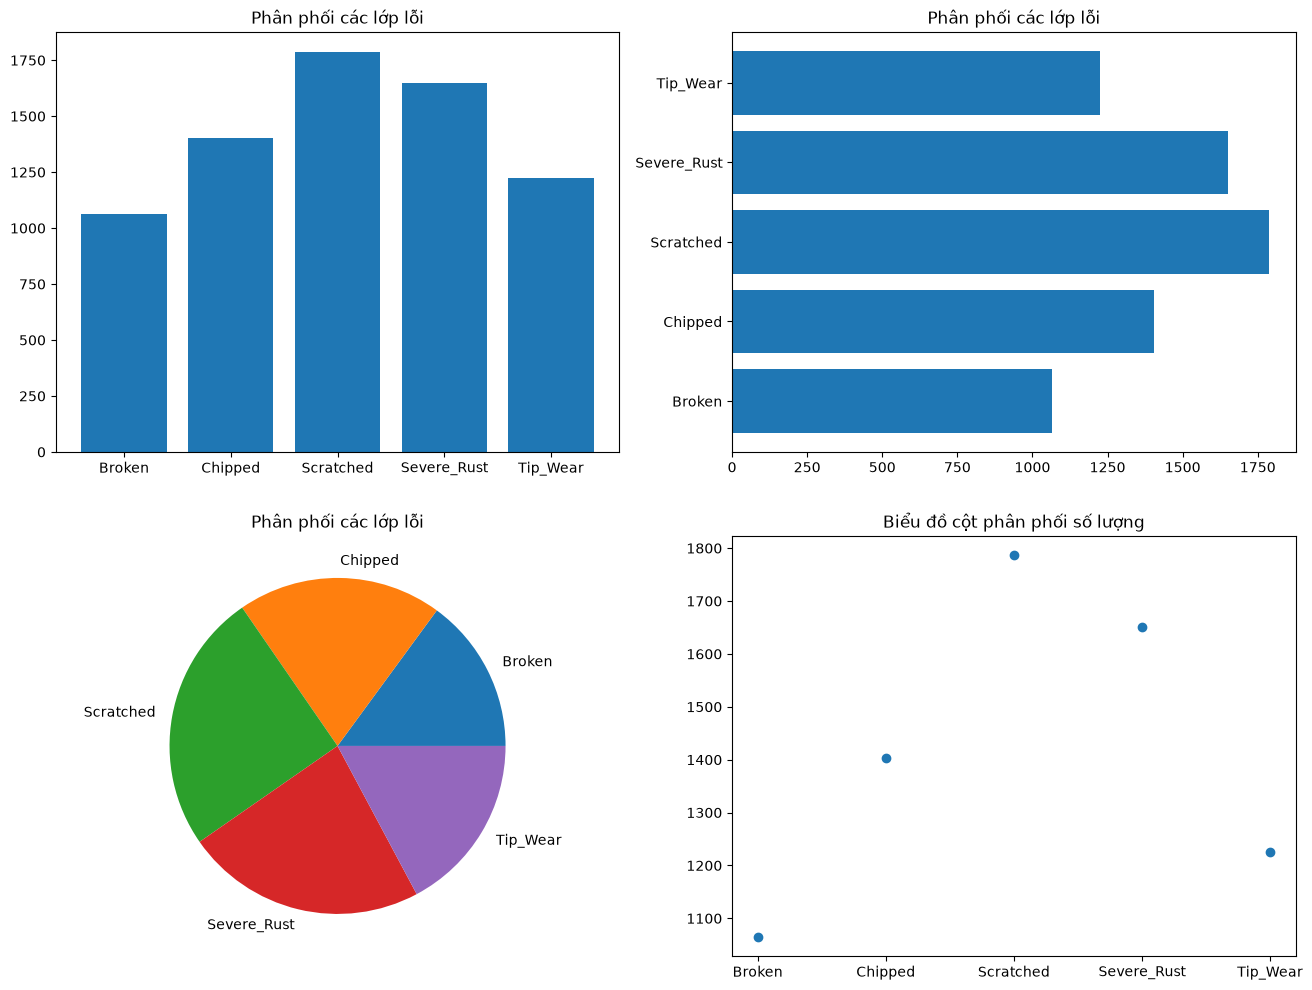

In [23]:
def visualize_class_distribution():
    names = []
    counts = []
    for class_id in range(NUM_ClASSES):
        names.append(CLASS_NAMES[class_id])
        counts.append(class_counts[class_id])
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0, 0].bar(names, counts)
    axes[0, 0].set_title("Phân phối các lớp lỗi")

    axes[0, 1].barh(names, counts)
    axes[0, 1].set_title("Phân phối các lớp lỗi")

    axes[1, 0].pie(counts, labels=names)
    axes[1, 0].set_title("Phân phối các lớp lỗi")

    axes[1, 1].scatter(names, counts)
    axes[1, 1].set_title("Biểu đồ cột phân phối số lượng")


    plt.show()
visualize_class_distribution()

# 5. Train Model YOLOv26

In [26]:
model = YOLO("yolo26n.pt")
results = model.train(data="/Users/mac/Detect_Drill_Bit/final-dataset/data.yaml", epochs=5, imgsz=640, device="mps", batch=16, workers=2, rect=True)

New https://pypi.org/project/ultralytics/8.4.80 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.75 🚀 Python-3.11.9 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/mac/Detect_Drill_Bit/final-dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=t

KeyboardInterrupt: 